In [1]:
%pip install "numpy" "opencv-python" -q
%pip install git+https://www.github.com/mouseland/cellpose.git
%pip install pyocclient -q
%pip install scikit-image -q



  Cloning https://www.github.com/mouseland/cellpose.git to /tmp/pip-req-build-y8xd0u2w
  Running command git clone --filter=blob:none --quiet https://www.github.com/mouseland/cellpose.git /tmp/pip-req-build-y8xd0u2w
  Resolved https://www.github.com/mouseland/cellpose.git to commit 94ae120369bdaea12da4921b81bc1fc7c8360558
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 108.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 90.2 MB/s eta 0:00:00:00:0100:01
  Created wheel for cellpose: filename=cellpose-4.1.2.dev28+g94ae12036-py3-none-any.whl size=214952 sha256=91806f981ac4a5620344a725463d028017d5a737401de5421483a62c11616852
  Stored in directory: /tmp/pip-ephem-wheel-cache-8wkr_lrg/wheels/df/b6/31/a3013c44290eabb46f4c06d1efb19744124fcad2d59684ec5e
Successfully built cellpose
  Preparing metadata (setup.py) ... done


In [2]:
# Cette commande est plus précise et remplace exactement la ligne que tu as copiée
!sed -i 's/if iepoch == 5 or iepoch % 10 == 0:/if True:/g' /usr/local/lib/python3.12/dist-packages/cellpose/train.py

In [3]:
!grep -nC 2 "if iepoch == 5 or iepoch % 10 == 0" /usr/local/lib/python3.12/dist-packages/cellpose/train.py


In [4]:
!grep -nC 2 "if True" /usr/local/lib/python3.12/dist-packages/cellpose/train.py

480-        train_losses[iepoch] /= nimg_per_epoch
481-
482:        if True:
483-            lavgt = 0.
484-            if test_data is not None or test_files is not None:


In [ ]:
# USEFULL TO UPLOAD DATA TO OWNCLLOUD, BUT NOT NEEDED FOR THE TOOL IF DATA IS ALREADY ON THE SERVER

# import owncloud, getpass, cellpose

# # Config
# url, user = 'url', 'user'
# oc_session = owncloud.Client(url)
# oc_session.login(user, getpass.getpass(f"PW {user}: "))
# oc_session.get_file('/travail/Mines/DIMA/Segmentation/scripts/tool.py', 'tool.py')

# import tool
# oc = tool.Owncloud(oc_session)

# print("Tool chargé et prêt.")

Tool chargé et prêt.


In [3]:
!nvcc --version
!nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Thu May  7 12:56:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0       

In [6]:
oc.upload_data()

In [7]:
oc.upload_scripts()

In [8]:
import os, shutil
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tool


from cellpose import core, utils, io, models, metrics, train, dynamics, transforms, plot
from glob import glob

import importlib
importlib.reload(tool)
import tool

visualizer = tool.CellVisualizer()

In [9]:

oc.upload_models()

In [ ]:
use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

In [10]:
import json

with open('./data/dataset_splits.json', 'r') as f:
    splits = json.load(f)

ids_train = splits['train']
ids_val   = splits['val']
ids_test  = splits['test']

print(f"Splits chargés : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")

Splits chargés : Train(71) | Val(10) | Test(21)


In [ ]:

io.logger_setup()

model = models.CellposeModel(gpu=True)

path = '001'
img = visualizer.load_data(path, target='Image')

masks_pred, flows, styles = model.eval(img, niter=1000)


output_dir = './data/prediction/cellpose4/'
os.makedirs(output_dir, exist_ok=True)

filename = os.path.basename(path)
name_without_ext = os.path.splitext(filename)[0]
save_path = os.path.join(output_dir, f"{name_without_ext}_Cell_pred.bmp")

cv2.imwrite(save_path, masks_pred)

print(f"Masque sauvegardé : {save_path}")

In [ ]:
true_mask = visualizer.load_data("001", target='Cell')

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i = "001", mask_pred=masks_pred, ax=ax1, show=False)
visualizer.plot(data = masks_pred, target = 'Cell_pred', ax=ax3, show=False)
visualizer.plot(i = "001", target='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()


ev = tool.Stats()


In [ ]:

import random


my_ids = ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010','011', '012', '013', '014', '015', '016', '017', '018', '019', '020','021', '022', '023', '024', '025', '026', '027', '028', '029', '030','031', '032', '033', '034', '035', '036', '037', '038', '039', '040','041', '042', '043', '044', '045', '046', '047', '048', '049', '050'] 


random.seed(42)
random.shuffle(my_ids)

n = len(my_ids)
ids_train = my_ids[:int(0.7 * n)]
ids_val   = my_ids[int(0.7 * n):int(0.8 * n)]
ids_test  = my_ids[int(0.8 * n):]

print(f"Split : Train({len(ids_train)}) | Val({len(ids_val)}) | Test({len(ids_test)})")



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import train, models, io
ev = tool.Stats()

X_train, Y_train = visualizer.load_channel(ids_train, mode= 'raw',target='Image')
X_val, Y_val     = visualizer.load_channel(ids_val, mode = 'raw',target='Image')

io.logger_setup()
learning_rates = [ 0.00005,0.00001,0.000005] 
fig, axes = plt.subplots(1, len(learning_rates), figsize=(15, 4))

resultats_lr = {}

for i, lr in enumerate(learning_rates):
    print(f"--- Test LR = {lr} ---")
    
    model = models.CellposeModel(model_type='cpsam', gpu=True)
    
    m_path, t_loss, v_loss = train.train_seg(
        model.net,
        train_data=X_train, train_labels=Y_train,
        test_data=X_val, test_labels=Y_val,
        n_epochs=20,         
        learning_rate=lr,
        weight_decay=0.0001,
        save_path='.',
        model_name=f'test_lr_{lr}'
    )
    
    total_tp, total_fp, total_fn = 0, 0, 0
    
    for idx, img_val in enumerate(X_val):
        true_mask = Y_val[idx]

        mask_pred, _, _ = model.eval(img_val, resample=True, channels=[1, 2])
        
        perf = ev.summary_perf(true_mask, mask_pred, iou_threshold=0.5)
        total_tp += perf['tp']
        total_fp += perf['fp']
        total_fn += perf['fn']
        
    if (total_tp + total_fp + total_fn) > 0:
        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
        recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    else:
        f1_score = 0.0
        
    resultats_lr[lr] = f1_score
    
    visualizer.plot_loss(t_loss, v_loss, title=f"LR = {lr} | F1 = {f1_score:.3f}", ax=axes[i], show=False)

plt.tight_layout()
plt.show()

# Affichage du résumé
print("Summary")
for lr, f1 in resultats_lr.items():
    print(f"LR: {lr} -> F1-Score: {f1:.4f}")

Type du premier élément X_train: <class 'numpy.ndarray'>
Type du premier élément Y_train: <class 'numpy.ndarray'>
Train set: 71 samples | Val set: 10 samples
[GUI INFO] : WRITING LOG OUTPUT TO /root/.cellpose/run.log

cellpose version: 	4.1.2.dev28+g94ae12036 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-05-07 14:39:52,516 [io INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-05-07 14:39:52,517 [io INFO] 
cellpose version: 	4.1.2.dev28+g94ae12036 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-05-07 14:39:52,518 [core INFO] ** TORCH CUDA version installed and working. **
2026-05-07 14:39:52,519 [core INFO] >>>> using GPU (CUDA)
2026-05-07 14:39:54,868 [models INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-05-07 14:39:55,749 [train INFO] >>> converting bfloat16 network to float32 for training
2026-05-07 14:39:55,758 [dynamics INFO] computing flows for labels


100%|██████████| 71/71 [00:02<00:00, 31.00it/s]

2026-05-07 14:39:58,076 [dynamics INFO] computing flows for labels



100%|██████████| 10/10 [00:00<00:00, 31.45it/s]

2026-05-07 14:39:58,400 [train INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 770.05it/s]

2026-05-07 14:39:58,507 [train INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-05-07 14:39:59,052 [train INFO] >>> n_epochs=40, n_train=71, n_test=10
2026-05-07 14:39:59,053 [train INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-05-07 14:39:59,054 [train INFO] >>> saving model to models/nuc_4
2026-05-07 14:40:09,330 [train INFO] 0, train_loss=2.1607, test_loss=1.8458, LR=0.000000, time 10.28s
2026-05-07 14:40:19,392 [train INFO] 1, train_loss=1.0348, test_loss=0.3824, LR=0.000001, time 20.34s
2026-05-07 14:40:29,441 [train INFO] 2, train_loss=0.4200, test_loss=0.3281, LR=0.000002, time 30.39s
2026-05-07 14:40:39,518 [train INFO] 3, train_loss=0.3741, test_loss=0.2635, LR=0.000003, time 40.46s
2026-05-07 14:40:49,575 [train INFO] 4, train_loss=0.3642, test_loss=0.2403, LR=0.000004, time 50.52s
2026-05-07 14:40:59,637 [train INFO] 5, train_loss=0.3194, test_loss=0.2511, LR=0.000006, time 60.58s
2026-05-07 14:41:09,657 [train INFO] 6, train_loss=0.3244, test_loss=0.2539, LR=0.000007, time 70.60s
2026-05-07 14:41:19,781 [train INFO] 7, train_lo

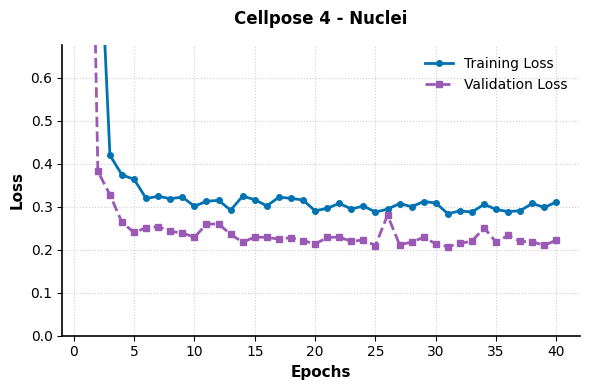

<Axes: title={'center': 'Cellpose 4 - Nuclei'}, xlabel='Epochs', ylabel='Loss'>

In [18]:
import matplotlib.pyplot as plt
import gc 
import torch
from cellpose import train, models, io

# Nettoyage immédiat après l'entraînement
gc.collect()
torch.cuda.empty_cache()

X_train,Y_train = visualizer.load_set(ids_train, annotation=True, target='Nuc')
X_val,Y_val   = visualizer.load_set(ids_val, annotation=True, target='Nuc')

print("Type du premier élément X_train:", type(X_train[0]))
print("Type du premier élément Y_train:", type(Y_train[0]))

print(f"Train set: {len(X_train)} samples | Val set: {len(X_val)} samples") 

io.logger_setup()
model_finetune = models.CellposeModel(gpu=True)

model_path, t_loss, v_loss = train.train_seg(
    model_finetune.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    n_epochs=40,          
    learning_rate= 1e-5,
    nimg_test_per_epoch =10,
    weight_decay=0.0001,
    save_path='.',
    model_name='nuc_4'
)

print(f"Modèle sauvegardé : {model_path}")

backup_path = "loss_backup_nuc4.json"

# Sécurité : on s'assure que ce sont bien des listes Python standards 
# (car json.dump déteste les numpy arrays)
safe_t_loss = t_loss.tolist() if hasattr(t_loss, 'tolist') else t_loss
safe_v_loss = v_loss.tolist() if hasattr(v_loss, 'tolist') else v_loss

with open(backup_path, "w") as f:
    json.dump({
        'train_loss': safe_t_loss, 
        'val_loss': safe_v_loss
    }, f, indent=4)

print(f"✅ SÉCURITÉ : Les données de Loss sont sauvées à l'abri dans '{backup_path}' !")
# ---------------------------------------------------------
# Nettoyage immédiat après l'entraînement
gc.collect()
torch.cuda.empty_cache()

# 3. Maintenant on peut faire le plot sans stress
visualizer.plot_loss(t_loss, v_loss, title="Cellpose 4 - Nuclei", show=True)



In [ ]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model='./models/cyto4_50.pth')

base_output = './data/prediction/cellpose4_cyto/'
output_dir_masks = os.path.join(base_output, 'masks/')
output_dir_viz = os.path.join(base_output, 'visualizations/')

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

ev = tool.Stats()
all_results = [] 

print("Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...")

for img_id in ids_val:
    img = visualizer.load_data(img_id, target='Image')
    true_mask = visualizer.load_data(img_id, target='Cell')
    
    masks, flows, styles = model.eval(img, resample=True,flow_threshold=0.4, cellprob_threshold=0.0)
    
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    

    perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
    all_results.append(perf)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
    ax1.set_title("A. Image Brute")

    visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target='Cell')
    ax2.set_title("B. Superposition ( vert expert, rouge cellpose)")
    
    visualizer.plot(i=img_id, target='Cell', ax=ax3, show=False)
    ax3.set_title("C. Masque Expert")
    
    visualizer.plot(data=masks, target='Cell_pred', ax=ax4, show=False)
    ax4.set_title("D. Prédiction Cellpose ")
    
    titre_rapport = (f"Rapport Image : {img_id} | "
                     f"F1-Score: {perf['f1']:.3f} | "
                     f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_rapport_complet.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    
    plt.close(fig)

df_final = ev.global_report(all_results, model_name=f"Cellpose4 cell")

In [ ]:
oc.download_path('/content/data/prediction/cellpose4_cyto/','/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_cyto')

In [ ]:
img_id = '065'
img = visualizer.load_data(img_id, target='Image')
true_mask = visualizer.load_data(img_id, target='Cell')
masks, flows, styles = model.eval(img, resample=True)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax1, show=False)
visualizer.plot(data=masks, target='Cell_pred', ax=ax3, show=False)
visualizer.plot(i=img_id, target='Cell', ax=ax2, show=False, title="Masque Expert")
plt.show()

In [ ]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model='./models/cyto4_50.pth')

base_output = './data/prediction/cellpose4_50/'
output_dir_masks = os.path.join(base_output, 'masks/')
output_dir_viz = os.path.join(base_output, 'visualizations/')

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

ev = tool.Stats()
all_results = [] 

print("Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...")

for img_id in ids_val:
    img = visualizer.load_data(img_id, target='Image')
    true_mask = visualizer.load_data(img_id, target='Cell')
    
    masks, flows, styles = model.eval(img, resample=True)
    
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    

    perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
    all_results.append(perf)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
    ax1.set_title("A. Image Brute")

    visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax4, show=False)
    ax4.set_title("B. Superposition")
    
    visualizer.plot(i=img_id, target='Cell', ax=ax2, show=False)
    ax2.set_title("C. Masque Expert")
    
    visualizer.plot(data=masks, target='Cell_pred', ax=ax3, show=False)
    ax3.set_title("D. Prédiction Cellpose ( vert expert, rouge cellpose)")
    
    titre_rapport = (f"Rapport Image : {img_id} | "
                     f"F1-Score: {perf['f1']:.3f} | "
                     f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_rapport_complet.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    
    plt.close(fig)

In [ ]:
oc.download_path('/content/data/prediction/cellpose4_50/','/travail/Mines/DIMA/Segmentation/data/prediction/DIMA_cellposeSAM_val')

[GUI INFO] : WRITING LOG OUTPUT TO /root/.cellpose/run.log

cellpose version: 	4.1.2.dev28+g94ae12036 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-05-07 14:57:42,370 [io INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-05-07 14:57:42,371 [io INFO] 
cellpose version: 	4.1.2.dev28+g94ae12036 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128


--- ENTRAÎNEMENT : target raw ---
2026-05-07 14:57:43,136 [core INFO] ** TORCH CUDA version installed and working. **
2026-05-07 14:57:43,136 [core INFO] >>>> using GPU (CUDA)
2026-05-07 14:57:45,447 [models INFO] >>>> loading model /root/.cellpose/models/cpsam
2026-05-07 14:57:46,382 [train INFO] >>> converting bfloat16 network to float32 for training
2026-05-07 14:57:46,392 [dynamics INFO] computing flows for labels


100%|██████████| 71/71 [00:07<00:00,  9.46it/s]

2026-05-07 14:57:53,939 [dynamics INFO] computing flows for labels



100%|██████████| 10/10 [00:01<00:00,  9.12it/s]

2026-05-07 14:57:55,049 [train INFO] >>> computing diameters



100%|██████████| 10/10 [00:00<00:00, 796.08it/s]

2026-05-07 14:57:55,153 [train INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': True, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2026-05-07 14:57:56,060 [train INFO] >>> n_epochs=40, n_train=71, n_test=10
2026-05-07 14:57:56,060 [train INFO] >>> AdamW, learning_rate=0.00001, weight_decay=0.00010
2026-05-07 14:57:56,062 [train INFO] >>> saving model to models/cyto4_40_n4_raw
2026-05-07 14:58:06,227 [train INFO] 0, train_loss=4.7634, test_loss=4.6032, LR=0.000000, time 10.17s
2026-05-07 14:58:16,294 [train INFO] 1, train_loss=4.0286, test_loss=3.2598, LR=0.000001, time 20.23s
2026-05-07 14:58:26,446 [train INFO] 2, train_loss=3.5880, test_loss=2.6446, LR=0.000002, time 30.38s
2026-05-07 14:58:36,539 [train INFO] 3, train_loss=3.3963, test_loss=2.6038, LR=0.000003, time 40.48s
2026-05-07 14:58:46,649 [train INFO] 4, train_loss=3.2506, test_loss=2.4844, LR=0.000004, time 50.59s
2026-05-07 14:58:56,826 [train INFO] 5, train_loss=3.2049, test_loss=2.5902, LR=0.000006, time 60.76s
2026-05-07 14:59:06,960 [train INFO] 6, train_loss=3.0839, test_loss=2.5261, LR=0.000007, time 70.90s
2026-05-07 14:59:17,082 [train INFO] 7

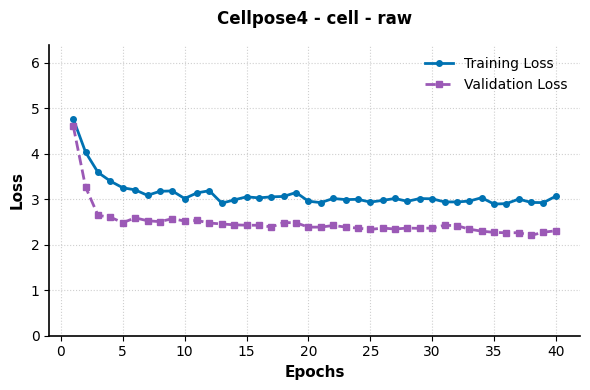

In [19]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

# Définition des modes à évaluer
modes_experimentaux = ['raw']

io.logger_setup()

for mode_actuel in modes_experimentaux:
    
    print(f"--- ENTRAÎNEMENT : target {mode_actuel} ---")

    X_train, Y_train = visualizer.load_channel(ids_train, mode=mode_actuel, target='Image', annotation=True)
    X_val, Y_val     = visualizer.load_set(ids_val, target='Cell', annotation=True)

    nom_modele = f'cyto4_40_n4_{mode_actuel.lower()}'

    # 3. Entraînement
    model_finetune = models.CellposeModel(gpu=True)

    model_path, t_loss, v_loss = train.train_seg(
        model_finetune.net,
        train_data=X_train,
        train_labels=Y_train,
        test_data=X_val,
        test_labels=Y_val,
        n_epochs=40,
        nimg_test_per_epoch=10,          
        learning_rate= 1e-5,
        weight_decay=0.0001,  
        save_path='.',
        model_name=nom_modele
    )

    print(f"Modèle {mode_actuel} sauvegardé avec succès : {model_path}")

    backup_path = "loss_backup_cell_raw4.json"

    # Sécurité : on s'assure que ce sont bien des listes Python standards 
    # (car json.dump déteste les numpy arrays)
    safe_t_loss = t_loss.tolist() if hasattr(t_loss, 'tolist') else t_loss
    safe_v_loss = v_loss.tolist() if hasattr(v_loss, 'tolist') else v_loss

    with open(backup_path, "w") as f:
        json.dump({
            'train_loss': safe_t_loss, 
            'val_loss': safe_v_loss
        }, f, indent=4)

    print(f"✅ SÉCURITÉ : Les données de Loss sont sauvées à l'abri dans '{backup_path}' !")
    # ---------------------------------------------------------
    # Nettoyage immédiat après l'entraînement
    gc.collect()
    torch.cuda.empty_cache()

    # 3. Maintenant on peut faire le plot sans stress
    visualizer.plot_loss(t_loss, v_loss, title="Cellpose4 - cell - raw", show=True)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io

io.logger_setup()
ev = tool.Stats()
# modes_experimentaux = ['raw', 'clahe', 'Nuc_Pred']
modes_experimentaux = ['raw']
for mode_actuel in modes_experimentaux:
    all_results = [] 
    nom_modele = f'cyto4_40_n4_{mode_actuel.lower()}'
    print(f"\n--- EVAL : target {nom_modele} ---")

    chemin_modele = f'./models/{nom_modele}'
    print(f"Chargement du modèle depuis : {chemin_modele}")
    model = models.CellposeModel(gpu=True, pretrained_model=chemin_modele)

    base_output = f'./data/prediction/cellpose4_{mode_actuel.lower()}/'
    output_dir_masks = os.path.join(base_output, 'masks/')
    output_dir_viz = os.path.join(base_output, 'visualizations/')

    os.makedirs(output_dir_masks, exist_ok=True)
    os.makedirs(output_dir_viz, exist_ok=True)

    X_val_multi, Y_val_true = visualizer.load_channel(ids_val, mode=mode_actuel, target='Image', annotation=True)

    for idx, img_id in enumerate(ids_val):
        img_stack = X_val_multi[idx]
        true_mask = Y_val_true[idx]
        
        masks, flows, styles = model.eval(
            img_stack, 
            channels=[1, 2], 
            resample=True, 
            flow_threshold=0.4, 
            cellprob_threshold=-0.5
        )
        
        save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
        cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
        
        # CORRECTION : Rapport dynamique
        nom_rapport = f"Cellpose_cyto4_{mode_actuel}"

        perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
        all_results.append(perf)
        
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))
        ax1, ax2, ax3, ax4 = axes.flatten()
        
        visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
        ax1.set_title("A. Image Brute")

        visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target='Cell')
        ax2.set_title("B. Superposition (vert expert, rouge cellpose)")
        
        visualizer.plot(i=img_id, target='Cell', ax=ax4, show=False)
        ax4.set_title("C. Masque Expert")
        
        visualizer.plot(data=masks, target='Cell_pred', ax=ax3, show=False)
        ax3.set_title("D. Prédiction Cellpose")
        
        titre_rapport = (f"Rapport Image : {img_id} (target : {mode_actuel.upper()}) | "
                        f"F1-Score: {perf['f1']:.3f} | "
                        f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
        
        fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        fig.subplots_adjust(top=0.85)
        
        save_path_viz = os.path.join(output_dir_viz, f"{img_id}_cell_pred_viz.png")
        plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
        plt.close(fig)
    df_final = ev.global_report(all_results, model_name=f"Cellpose cyto4 {mode_actuel}")
    oc.download_path(base_output,f'/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_{mode_actuel.lower()}')


print("\nÉvaluation terminée. Vous pouvez maintenant afficher le DataFrame all_results.")

In [ ]:
import matplotlib.pyplot as plt
from cellpose import train, models, io

X_train,Y_train = visualizer.load_set(ids_train, target='Nuc')
X_val,Y_val   = visualizer.load_set(ids_val, target='Nuc')

io.logger_setup()
model_finetune = models.CellposeModel(gpu=True)

model_path, t_loss, v_loss = train.train_seg(
    model_finetune.net,
    train_data=X_train,
    train_labels=Y_train,
    test_data=X_val,
    test_labels=Y_val,
    n_epochs=40,          
    learning_rate= 1e-5,
    weight_decay=0.0001,  
    save_path='.',
    model_name='cellpose4_nuclei'
)

print(f"Modèle sauvegardé : {model_path}")

visualizer.plot_loss(t_loss, v_loss, title=f"LR = {0.05}",show=True)


In [ ]:
oc.oc.put_file(
    '/travail/Mines/DIMA/Segmentation/results/models/cellpose4_nuclei.pth',
    'models/cellpose4_nuclei', timeout=600                                  
)

In [ ]:
io.logger_setup()
model = models.CellposeModel(gpu=True, pretrained_model= './models/cellpose4_nuclei.pth')

base_output = './data/prediction/cellpose4_nuclei_ct_-0.5/'
output_dir_masks = os.path.join(base_output, 'masks/')
output_dir_viz = os.path.join(base_output, 'visualizations/')

os.makedirs(output_dir_masks, exist_ok=True)
os.makedirs(output_dir_viz, exist_ok=True)

ev = tool.Stats()
all_results = [] 

print("Début du traitement, de l'évaluation et de l'export des visualisations (planche 4 images)...")

for img_id in ids_val:
    img = visualizer.load_data(img_id, target='Image')
    true_mask = visualizer.load_data(img_id, target='Nuc')
    
    masks, flows, styles = model.eval(img, resample=True,flow_threshold=0.4, cellprob_threshold=-0.5)
    
    save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Nuc_pred.bmp")
    cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
    

    perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
    all_results.append(perf)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 20))
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
    ax1.set_title("A. Image Brute")

    visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target='Nuc')
    ax2.set_title("B. Superposition ( vert expert, rouge cellpose)")
    
    visualizer.plot(i=img_id, target='Nuc', ax=ax3, show=False)
    ax3.set_title("C. Masque Expert")
    
    visualizer.plot(data=masks, target='Nuc_pred', ax=ax4, show=False)
    ax4.set_title("D. Prédiction Cellpose ")
    
    titre_rapport = (f"Rapport Image : {img_id} | "
                     f"F1-Score: {perf['f1']:.3f} | "
                     f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
    
    fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    
    save_path_viz = os.path.join(output_dir_viz, f"{img_id}_rapport_complet.png")
    plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
    
    plt.close(fig)

df_final = ev.global_report(all_results, model_name=f"Cellpose4 nuclei ct_-0.5")

In [ ]:
oc.download_path('/content/data/prediction/cellpose4_nuclei_ct_-0.5','/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_ct_-0.5')

In [ ]:
import numpy as np

# Mélange aléatoire mais reproductible de vos identifiants
ids_shuffled = np.random.RandomState(42).permutation(ids_train)

# Découpage strict en 4 blocs (arrays)
blocs = np.array_split(ids_shuffled, 4)

# Conversion en listes simples
ids_A = blocs[0].tolist()
ids_B = blocs[1].tolist()
ids_C = blocs[2].tolist()
ids_D = blocs[3].tolist()

In [ ]:
print(f"Fold A - Train: {len(ids_A)}")

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import train, models, io

# Itération sur les 4 Folds
for name, ids_ in zip(['A', 'B', 'C', 'D'], [ids_A, ids_B, ids_C, ids_D]):
    print(f"\n--- Début de l'entraînement pour le Fold {name} ---")

    # 1. Exclusion sécurisée du Fold courant pour l'entraînement (Out-of-Fold)
    train_fold_ids = [i for i in ids_train if i not in ids_]
    
    # Chargement des données
    X_train, Y_train = visualizer.load_set(train_fold_ids, target='Nuc')
    X_val, Y_val     = visualizer.load_set(ids_val, target='Nuc')

    base_output = f'./data/prediction/cellpose4_nuclei_{name}/'
    output_dir_masks = os.path.join(base_output, 'masks/')
    output_dir_viz = os.path.join(base_output, 'visualizations/')

    os.makedirs(output_dir_masks, exist_ok=True)
    os.makedirs(output_dir_viz, exist_ok=True)

    ev = tool.Stats()
    all_results = [] 

    io.logger_setup()
    model_finetune = models.CellposeModel(gpu=True)

    model_path, t_loss, v_loss = train.train_seg(
        model_finetune.net,
        train_data=X_train,
        train_labels=Y_train,
        test_data=X_val,
        test_labels=Y_val,
        n_epochs=40,          
        learning_rate= 1e-5,
        weight_decay=0.0001,  
        save_path='.',
        model_name=f'cellpose4_nuclei_{name}'
)

    print(f"--- Inférence et Évaluation sur le Fold {name} ---")
    
    # 3. Correction de la variable de boucle
    for img_id in ids_:
        img = visualizer.load_data(img_id, target='Image')
        true_mask = visualizer.load_data(img_id, target='Nuc')
        
        # 4. Appel correct du modèle fine-tuné
        masks, flows, styles = model_finetune.eval(
            img, 
            resample=True, 
            flow_threshold=0.4, 
            cellprob_threshold=-0.5
        )
        
        save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Nuc_pred.bmp")
        cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
        
        # Rapport statistique

        perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
        
        all_results.append(perf)
        # Création de la figure
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))
        ax1, ax2, ax3, ax4 = axes.flatten()
        
        visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
        ax1.set_title("A. Image Brute")

        visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target='Nuc')
        ax2.set_title("B. Superposition (vert expert, rouge cellpose)")
        
        visualizer.plot(i=img_id, target='Nuc', ax=ax4, show=False)
        ax4.set_title("C. Masque Expert")
        
        visualizer.plot(data=masks, target='Nuc_pred', ax=ax3, show=False)
        ax3.set_title("D. Prédiction Cellpose")
        
        titre_rapport = (f"Rapport Image : {img_id} (Fold {name}) | "
                        f"F1-Score: {perf['f1']:.3f} | "
                        f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
        
        fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        fig.subplots_adjust(top=0.85)
        
        save_path_viz = os.path.join(output_dir_viz, f"{img_id}_nuc_pred_viz.png")
        plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
        
        plt.close(fig)
        
    visualizer.plot_loss(t_loss, v_loss[1:], title=f"Perte Fold {name} (LR = 0.05)", show=True)
    oc.download_path(f'/content/data/prediction/cellpose4_nuclei_{name}', f'/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_nuclei_train{name}')

print("Validation croisée terminée avec succès.")

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io

io.logger_setup()
ev = tool.Stats()
# modes_experimentaux = ['raw', 'clahe', 'Nuc_Pred']
modes_experimentaux = ['Nuc_Pred']
for mode_actuel in modes_experimentaux:
    all_results = [] 
    nom_modele = f'cyto4_40_n4_{mode_actuel.lower()}'
    print(f"\n--- EVAL : target {nom_modele} ---")

    chemin_modele = f'./models/{nom_modele}'
    print(f"Chargement du modèle depuis : {chemin_modele}")
    model = models.CellposeModel(gpu=True, pretrained_model=chemin_modele)

    base_output = f'./data/prediction/cellpose4_n4_{mode_actuel.lower()}/'
    output_dir_masks = os.path.join(base_output, 'masks/')
    output_dir_viz = os.path.join(base_output, 'visualizations/')

    os.makedirs(output_dir_masks, exist_ok=True)
    os.makedirs(output_dir_viz, exist_ok=True)

    X_val_multi, Y_val_true = visualizer.load_channel(ids_val, mode=mode_actuel, target='Image')

    for idx, img_id in enumerate(ids_val):
        img_stack = X_val_multi[idx]
        true_mask = Y_val_true[idx]
        
        masks, flows, styles = model.eval(
            img_stack, 
            channels=[1, 2], 
            resample=True, 
            flow_threshold=0.4, 
            cellprob_threshold=0.0
        )
        
        save_path_mask = os.path.join(output_dir_masks, f"{img_id}_Cell_pred.bmp")
        cv2.imwrite(save_path_mask, masks.astype(np.uint16)) 
        
        # CORRECTION : Rapport dynamique
        nom_rapport = f"Cellpose_cyto4_n4_{mode_actuel}"

        perf = ev.summary_perf(true_mask, masks, iou_threshold=0.5)
        all_results.append(perf)
        
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))
        ax1, ax2, ax3, ax4 = axes.flatten()
        
        visualizer.plot(i=img_id, target='Image', ax=ax1, show=False)
        ax1.set_title("A. Image Brute")

        visualizer.plot_overlay(i=img_id, mask_pred=masks, ax=ax2, show=False, target='Cell')
        ax2.set_title("B. Superposition (vert expert, rouge cellpose)")
        
        visualizer.plot(i=img_id, target='Cell', ax=ax4, show=False)
        ax4.set_title("C. Masque Expert")
        
        visualizer.plot(data=masks, target='Cell_pred', ax=ax3, show=False)
        ax3.set_title("D. Prédiction Cellpose")
        
        titre_rapport = (f"Rapport Image : {img_id} (target : {mode_actuel.upper()}) | "
                        f"F1-Score: {perf['f1']:.3f} | "
                        f"TP : {perf['tp']} , FP : {perf['fp']} , FN : {perf['fn']}")
        
        fig.suptitle(titre_rapport, fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        fig.subplots_adjust(top=0.85)
        
        save_path_viz = os.path.join(output_dir_viz, f"{img_id}_cell_pred_viz.png")
        plt.savefig(save_path_viz, dpi=150, bbox_inches='tight')
        plt.close(fig)
    df_final = ev.global_report(all_results, model_name=f"Cellpose cyto4 n4 {mode_actuel}")
    oc.download_path(base_output,f'/travail/Mines/DIMA/Segmentation/data/prediction/cellpose4_n4_{mode_actuel.lower()}')


print("\nÉvaluation terminée. Vous pouvez maintenant afficher le DataFrame all_results.")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io

io.logger_setup()
ev = tool.Stats()

mode_actuel = 'Nuc'
nom_modele = f'cellpose4_nuclei'
chemin_modele = './models/cellpose4_nuclei.pth'

model = models.CellposeModel(gpu=True, pretrained_model=chemin_modele)
# X_val_multi, Y_val_true = visualizer.load_channel(ids_val, target=mode_actuel)

X_val_multi, Y_val_true = visualizer.load_set(ids_val, target='Nuc')


# Grille de recherche
flow_thresholds = [0.0,0.3,0.4, 0.5]
cellprob_thresholds = [ -0.6,-0.5]

# Initialisation de DEUX subplots
fig, (ax_f1, ax_fn) = plt.subplots(1, 2, figsize=(18, 6))

# CORRECTION : Création du dictionnaire d'archivage
stockage_resultats_bruts = {}

for f_t in flow_thresholds:
    for c_t in cellprob_thresholds:

        # CORRECTION : Nom de variable unifié
        all_results_combinaison = [] 
        masks_pred_list = [] 

        nom_complet = f"Flow: {f_t} | CellProb: {c_t}"
        print(f"Calcul en cours : {nom_complet}...")

        for idx, img_id in enumerate(ids_val):
            img_stack = X_val_multi[idx]
            true_mask = Y_val_true[idx]
            
            masks, _, _ = model.eval(
                img_stack, 
                # channels=[1, 2], 
                resample=True, 
                flow_threshold=f_t, 
                cellprob_threshold=c_t
            )
            
            masks_pred_list.append(masks)
            all_results_combinaison.append(perf := ev.summary_perf(true_mask, masks, iou_threshold=0.5))

        # On trace la courbe sur l'axe de comparaison
        ev.plot_f1_vs_iou(Y_val_true, masks_pred_list, ax=(ax_f1, ax_fn), show=False)
        
        if ax_f1.lines:
            ax_f1.lines[-1].set_label(nom_complet)
            ax_fn.lines[-1].set_label(nom_complet)
            
        # CORRECTION : Archivage des résultats pour cette combinaison
        stockage_resultats_bruts[nom_complet] = all_results_combinaison

# Formatage final global
ax_f1.set_title("Optimisation de la précision géométrique (F1-Score)", fontweight='bold')
ax_fn.set_title("Évaluation des rejets (Faux Négatifs)", fontweight='bold')

# Une seule légende placée sur le second graphique
ax_fn.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Génération successive de tous les rapports globaux
print("\n--- GÉNÉRATION DES RAPPORTS DÉTAILLÉS ---")
for nom_complet, resultats in stockage_resultats_bruts.items():
    print(f"\nReport pour {nom_complet} :")
    df_final = ev.global_report(resultats, model_name=f"{nom_modele} - {nom_complet}")